In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Import and interpolate NIST data

In [2]:
NIST = pd.read_excel(r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\X-ray spectrum calculations\NIST data water.xlsx")
#convert to keV
NIST['Energy'] = 1000*NIST['Energy']
#Calculate mass energy absorption over mass attenuation ratio
NIST['Ratio'] = NIST['Mass En Abs']/NIST['Mass Att']
#Truncate after Energy that is relevant for us
NIST = NIST.iloc[0:NIST[NIST['Energy']>225].index.tolist()[0]+1]
#Remove 1.5 keV
NIST = NIST[NIST['Energy']!=1.5]
NIST = NIST.reset_index(drop=True)
print(NIST)

    Energy   Mass Att  Mass En Abs     Ratio
0      1.0  4078.0000   4065.00000  0.996812
1      2.0   617.3000    615.20000  0.996598
2      3.0   192.9000    191.70000  0.993779
3      4.0    82.7800     81.91000  0.989490
4      5.0    42.5800     41.88000  0.983560
5      6.0    24.6400     24.05000  0.976055
6      8.0    10.3700      9.91500  0.956123
7     10.0     5.3290      4.94400  0.927754
8     15.0     1.6730      1.37400  0.821279
9     20.0     0.8096      0.55030  0.679718
10    30.0     0.3756      0.15570  0.414537
11    40.0     0.2683      0.06947  0.258927
12    50.0     0.2269      0.04223  0.186117
13    60.0     0.2059      0.03190  0.154930
14    80.0     0.1837      0.02597  0.141372
15   100.0     0.1707      0.02546  0.149151
16   150.0     0.1505      0.02764  0.183654
17   200.0     0.1370      0.02967  0.216569
18   300.0     0.1186      0.03192  0.269140


In [3]:
#Make a copy for interpolation, take over values from original data
Expanded_data = pd.DataFrame(columns=['Energy', 'Mass Att', 'Mass En Abs'])
Expanded_data['Energy'] = np.arange(1, 301, 1)
for energy in Expanded_data['Energy']:
    matching_location = NIST[NIST['Energy']==energy].index.tolist()
    if matching_location:
        Expanded_data.loc[(Expanded_data['Energy']==energy), 'Mass Att'] = NIST.loc[matching_location[0], 'Mass Att']
        Expanded_data.loc[(Expanded_data['Energy']==energy), 'Mass En Abs'] = NIST.loc[matching_location[0], 'Mass En Abs']

     Energy  Mass Att Mass En Abs     Ratio
0         1    4078.0      4065.0  0.996812
1         2     617.3       615.2  0.996598
2         3     192.9       191.7  0.993779
3         4     82.78       81.91   0.98949
4         5     42.58       41.88   0.98356
..      ...       ...         ...       ...
295     296  0.119336     0.03183  0.266726
296     297  0.119152    0.031852  0.267327
297     298  0.118968    0.031875  0.267929
298     299  0.118784    0.031897  0.268534
299     300    0.1186     0.03192   0.26914

[300 rows x 4 columns]


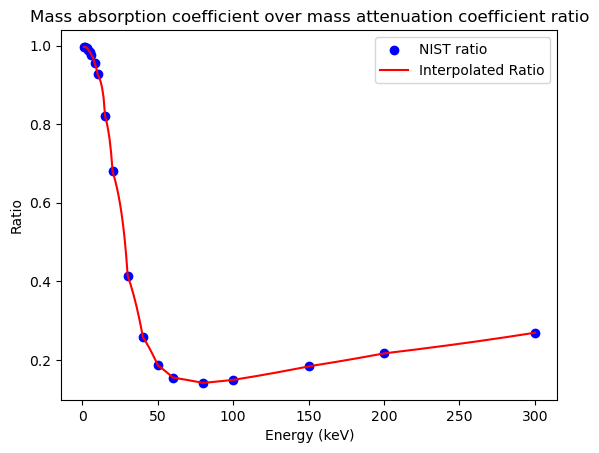

In [4]:
#Linear interpolation between existing points
for i in range(len(NIST)):
    if i!=len(NIST)-1:
        first_point = i
        second_point = i+1

        first_energy = NIST.loc[first_point, 'Energy']
        second_energy = NIST.loc[second_point, 'Energy']

        first_massatt = NIST.loc[first_point, 'Mass Att']
        second_massatt = NIST.loc[second_point, 'Mass Att']

        first_massen = NIST.loc[first_point, 'Mass En Abs']
        second_massen = NIST.loc[second_point, 'Mass En Abs']

        if (second_energy-first_energy) > 1:
            #interpolate
            interpolated_energies = np.arange(first_energy+1, second_energy, 1)
            xvals = np.array([first_energy, second_energy])

            interpolated_massatt = np.interp(interpolated_energies, xvals, np.array([first_massatt, second_massatt]))
            interpolated_massen = np.interp(interpolated_energies, xvals, np.array([first_massen, second_massen]))
            
            for en in interpolated_energies:
                Expanded_data.loc[Expanded_data['Energy']==en,'Mass Att'] = interpolated_massatt[np.where(interpolated_energies==en)]
                Expanded_data.loc[Expanded_data['Energy']==en,'Mass En Abs'] = interpolated_massen[np.where(interpolated_energies==en)]

Expanded_data['Ratio'] = Expanded_data['Mass En Abs']/Expanded_data['Mass Att']
print(Expanded_data)   

plt.scatter(NIST['Energy'],NIST['Ratio'], color='b', label='NIST ratio')
plt.plot(Expanded_data['Energy'], Expanded_data['Ratio'], color='r', label='Interpolated Ratio')
plt.title('Mass absorption coefficient over mass attenuation coefficient ratio')
plt.xlabel('Energy (keV)')
plt.ylabel('Ratio')
plt.legend()        

# Read in spectrum from SpekCalc

     Energy           N
0        23  5173756.00
1        24  6060958.00
2        25  6872044.00
3        26  7673581.00
4        27  8395098.00
..      ...         ...
198     221   134945.20
199     222   100379.00
200     223    66337.49
201     224    32881.67
202     225        0.00

[203 rows x 2 columns]


Text(0, 0.5, 'N (keV cm^2 mAs)^-1')

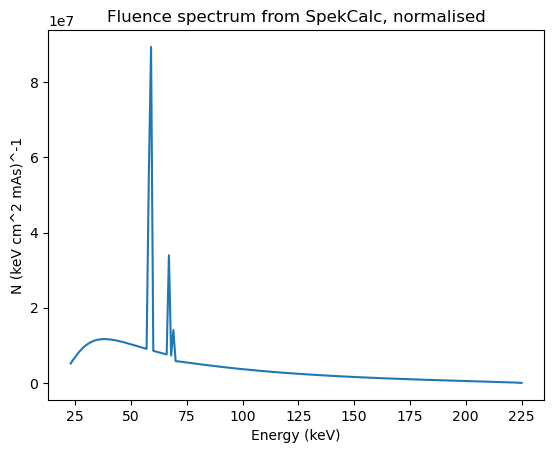

In [5]:
spectrum = pd.read_csv(r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\X-ray spectrum calculations\225kVp 30deg 525Air 2Be 2Al 0Cu 0Sn 0W 0Ta 0Ti 0C 0Wa.spec", sep=' ')
spectrum = spectrum[['Energy', 'N']].copy()

print(spectrum)
plt.plot(spectrum['Energy'], spectrum['N'])
plt.title('Fluence spectrum from SpekCalc, normalised')
plt.xlabel('Energy (keV)')
plt.ylabel('N (keV cm^2 mAs)^-1')

# Calculate absorption factor

In [6]:
#Thickness of material
x = 0.2 #cm
#Calculate absorption of each energy as 1-exp(-mu*x)
for i in range(len(spectrum)):
    mu = Expanded_data.loc[(Expanded_data['Energy']==spectrum.loc[i,'Energy']),'Mass Att']
    mu = mu.iloc[0]
    spectrum.loc[i, 'Absorption'] = 1 - np.exp(-1*mu*x)

print(spectrum)


     Energy           N  Absorption
0        23  5173756.00    0.127053
1        24  6060958.00    0.119442
2        25  6872044.00    0.111766
3        26  7673581.00    0.104023
4        27  8395098.00    0.096212
..      ...         ...         ...
198     221   134945.20    0.026276
199     222   100379.00    0.026240
200     223    66337.49    0.026204
201     224    32881.67    0.026168
202     225        0.00    0.026132

[203 rows x 3 columns]


Text(0, 0.5, 'Absorption factor')

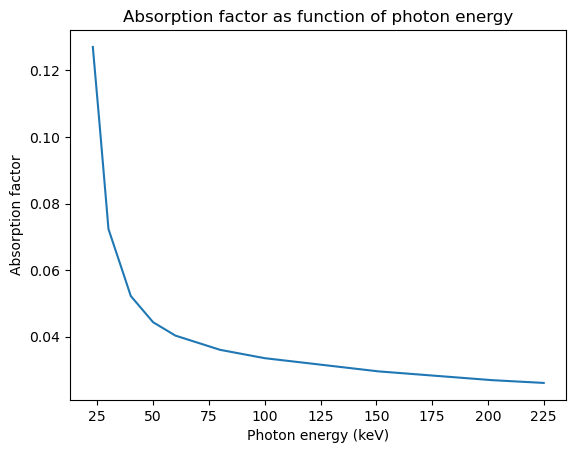

In [7]:
plt.plot(spectrum['Energy'], spectrum['Absorption'])
plt.title('Absorption factor as function of photon energy')
plt.xlabel('Photon energy (keV)')
plt.ylabel('Absorption factor')

     Energy         N
0        23  0.015599
1        24  0.017179
2        25  0.018226
3        26  0.018942
4        27  0.019167
..      ...       ...
198     221  0.000084
199     222  0.000063
200     223  0.000041
201     224  0.000020
202     225  0.000000

[203 rows x 2 columns]


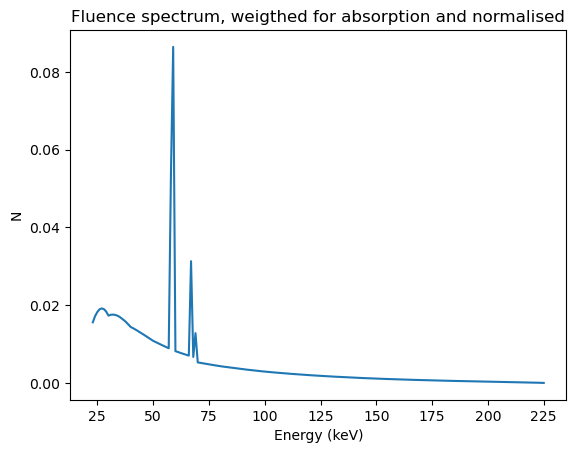

In [8]:
#Weight spectrum by absorption
spectrum['N'] = spectrum['N']*spectrum['Absorption']

#Normalise
spectrum['N'] = spectrum['N']/spectrum['N'].sum()

plt.plot(spectrum['Energy'], spectrum['N'])
plt.title('Fluence spectrum, weigthed for absorption and normalised')
plt.xlabel('Energy (keV)')
plt.ylabel('N')

spectrum.drop(columns='Absorption', inplace=True)
print(spectrum)

# Calculations with spectrum

C:\Users\bhaan\AppData\Local\Temp\ipykernel_2000\1630289461.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  vals[i] = energy*ratio


Text(0, 0.5, 'Electron energy (keV)')

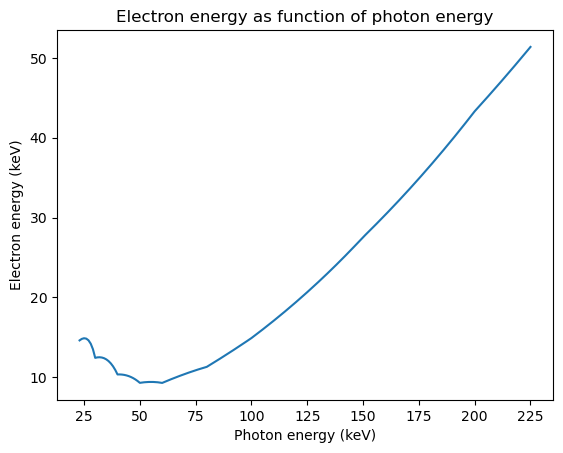

In [9]:
vals = np.zeros(len(spectrum))
for i in range(len(spectrum)):
    energy = spectrum.loc[i, 'Energy']

    #Ratio
    ratio = Expanded_data.loc[Expanded_data['Energy']==energy, 'Ratio']

    #Resulting energy
    vals[i] = energy*ratio

spectrum['Electron energy'] = vals
plt.plot(spectrum['Energy'], spectrum['Electron energy'])
plt.title('Electron energy as function of photon energy')
plt.xlabel('Photon energy (keV)')
plt.ylabel('Electron energy (keV)')


In [10]:
#Convert to MeV
spectrum['Energy'] = spectrum['Energy']/1000
spectrum['Electron energy'] = spectrum['Electron energy']/1000

#Store for estar copy/paste
#spectrum.to_excel(r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\X-ray spectrum calculations\Electron_energies.xlsx", index=False)

# Import and work with estar data

In [11]:
estar = pd.read_excel(r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\X-ray spectrum calculations\Estar data.xlsx")
estar.drop_duplicates(inplace=True)
print(estar)

     Kinetic Energy  Stopping Power
0            0.0010          119.80
1            0.0015           91.77
2            0.0020           75.22
3            0.0025           64.17
4            0.0030           56.21
..              ...             ...
275        600.0000           18.24
276        700.0000           20.98
277        800.0000           23.71
278        900.0000           26.45
279       1000.0000           29.19

[279 rows x 2 columns]


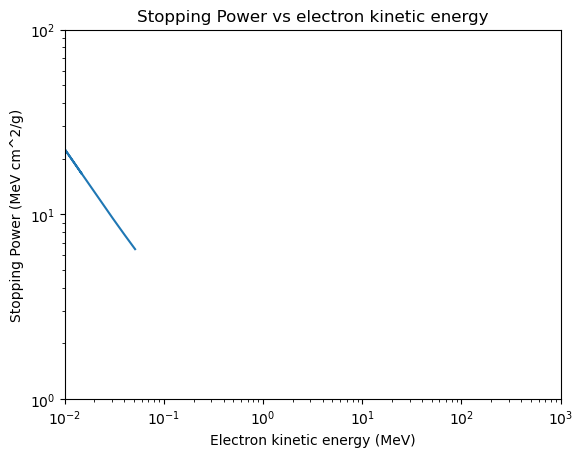

In [12]:
#Write stopping powers to existing spectrum data
vals = np.zeros(len(spectrum))
for i in range(len(spectrum)):
    energy = round(spectrum.loc[i, 'Electron energy'],5)
    sp = estar.loc[round(estar['Kinetic Energy'],5)==energy, 'Stopping Power']
    vals[i] = sp.iloc[0]
spectrum['Stopping Power'] = vals

plt.plot(spectrum['Electron energy'], spectrum['Stopping Power'])
plt.title('Stopping Power vs electron kinetic energy')
plt.xlabel('Electron kinetic energy (MeV)')
plt.ylabel('Stopping Power (MeV cm^2/g)')
plt.xlim([0.01, 1000])
plt.ylim([1, 100])
plt.xscale('log')
plt.yscale('log')

Shows good comparison to the estar result
![alt text](<../X-ray spectrum calculations/Estar result.png>)

In [13]:
#Weight all stopping powers using the fluence
spectrum['Weighted SP'] = spectrum['N']*spectrum['Stopping Power']
spectrum['Weighted SP squared'] = spectrum['N']*spectrum['Stopping Power']*spectrum['Stopping Power']
print(spectrum.to_string())

     Energy         N  Electron energy  Stopping Power  Weighted SP  Weighted SP squared
0     0.023  0.015599         0.014622          16.800     0.262056             4.402548
1     0.024  0.017179         0.014810          16.630     0.285686             4.750951
2     0.025  0.018226         0.014892          16.560     0.301823             4.998183
3     0.026  0.018942         0.014843          16.610     0.314623             5.225896
4     0.027  0.019167         0.014631          16.790     0.321810             5.403194
5     0.028  0.018973         0.014207          17.180     0.325950             5.599822
6     0.029  0.018347         0.013507          17.870     0.327857             5.858809
7     0.030  0.017315         0.012436          19.050     0.329858             6.283791
8     0.031  0.017523         0.012496          18.980     0.332588             6.312514
9     0.032  0.017581         0.012511          18.960     0.333344             6.320201
10    0.033  0.017500

In [15]:
#Take mean
Mean_SP_track = spectrum['Weighted SP'].mean()
Mean_SP_dose = spectrum['Weighted SP squared'].mean()

#Convert to LET in keV/um, taking into account the square of the stopping power
LET_t = 10*Mean_SP_track
LET_d = Mean_SP_dose

print('Track avg LET of X-rays: ' + str(round(LET_t,2)) + ' keV/um')
print('Dose avg LET of X-rays: ' + str(round(LET_d,2)) + ' keV/um')

Track avg LET of X-rays: 0.98 keV/um
Dose avg LET of X-rays: 2.02 keV/um
